# Optimization for Function 1

Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

Input: 2D array (10,2)

Output: 1D array (10,)

Goal: Maximise the black-box function using Bayesian Optimization.

Row   | Input Coordinates (X)                                             | Result (y)
--------------------------------------------------------------------------------------------------------------
0     | [0.319404, 0.762959]                                              | 0.0000000000

1     | [0.574329, 0.879898]                                              | 0.0000000000

2     | [0.731024, 0.733   ]                                              | 0.0000000000

3     | [0.840353, 0.264732]                                              | 0.0000000000

4     | [0.650114, 0.681526]                                              | -0.0036060626

5     | [0.410437, 0.147554]                                              | -0.0000000000

6     | [0.312691, 0.078723]                                              | -0.0000000000

7     | [0.683418, 0.861057]                                              | 0.0000000000

8     | [0.082507, 0.403488]                                              | 0.0000000000

9     | [0.88389 , 0.582254]                                              | 0.0000000000

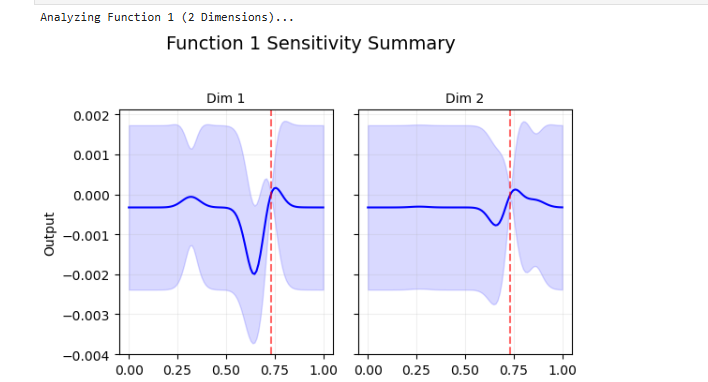


--- Function 1 Analysis ---
Max Value Found: 0.0000000000


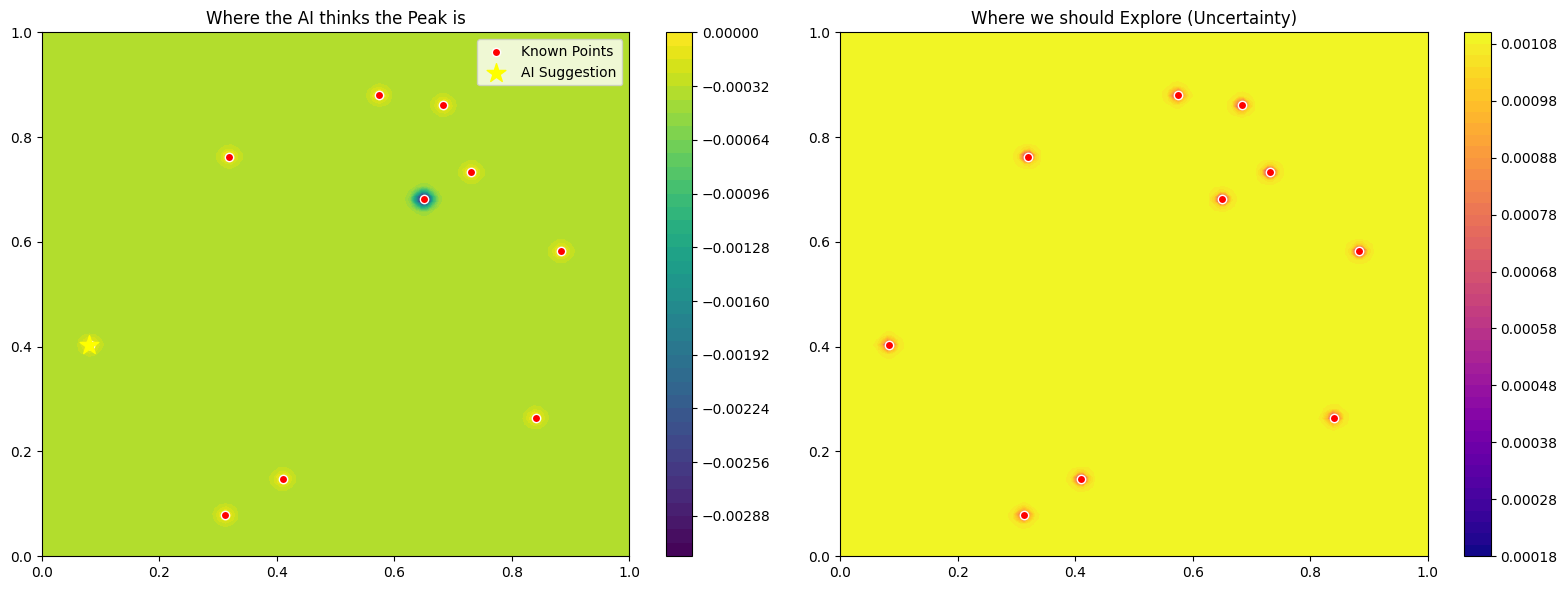


--- WEEK 1 RECOMMENDATION ---
Test these coordinates next: [0.080808, 0.404040]


In [12]:
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.exceptions import ConvergenceWarning

# 1. Setup & Ignore numerical warnings caused by 'flat' data
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# 2. Load Data for Function 1
fn_num = '1'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

print(f"--- Function {fn_num} Analysis ---")
print(f"Max Value Found: {np.max(y):.10f}")

# 3. Setup the Gaussian Process
# alpha=1e-5 adds stability when many outputs are identical
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-5, 
    normalize_y=True, 
    n_restarts_optimizer=25
)

# 4. Fit the model
gp.fit(X, y)

# 5. Create a Prediction Grid (100x100)
x_range = np.linspace(0, 1, 100)
y_range = np.linspace(0, 1, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.c_[X_grid.ravel(), Y_grid.ravel()]

# 6. Predict Mean and Uncertainty
y_pred, sigma = gp.predict(grid_points, return_std=True)
Z_mean = y_pred.reshape(X_grid.shape)
Z_sigma = sigma.reshape(X_grid.shape)

# 7. Identify the Next Coordinate to test
max_idx = np.argmax(y_pred)
best_x = grid_points[max_idx]

# 8. Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Map 1: Predicted Landscape (The Search for the Peak)
contour1 = ax1.contourf(X_grid, Y_grid, Z_mean, levels=50, cmap='viridis')
ax1.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Known Points')
ax1.scatter(best_x[0], best_x[1], c='yellow', marker='*', s=200, label='AI Suggestion')
ax1.set_title('Where the AI thinks the Peak is')
plt.colorbar(contour1, ax=ax1)
ax1.legend()

# Map 2: Uncertainty (Where we lack information)
contour2 = ax2.contourf(X_grid, Y_grid, Z_sigma, levels=50, cmap='plasma')
ax2.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white')
ax2.set_title('Where we should Explore (Uncertainty)')
plt.colorbar(contour2, ax=ax2)

plt.tight_layout()
plt.show()

print(f"\n--- WEEK 1 RECOMMENDATION ---")
print(f"Test these coordinates next: [{best_x[0]:.6f}, {best_x[1]:.6f}]")



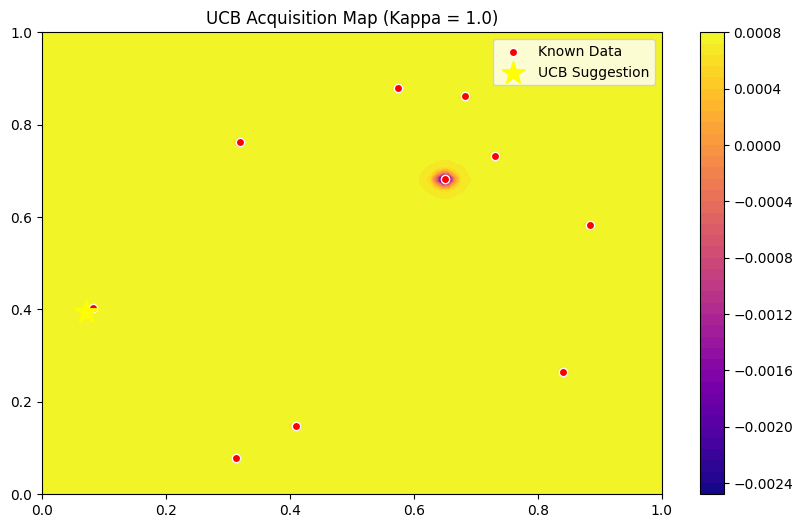

With Kappa=1.0, the AI suggests: [0.070707, 0.393939]


In [13]:
# --- ACQUISITION FUNCTION SETTINGS ---
# Set kappa LOW (e.g., 0.1) to zoom in on that -0.0036 "leak"
# Set kappa HIGH (e.g., 5.0) to ignore the leak and look in empty spaces
kappa = 1.0 

# 1. Calculate the UCB Score for every point on our grid
# We want to MAXIMISE this score
ucb_score = y_pred + (kappa * sigma)

# 2. Find the index of the highest UCB score
best_idx = np.argmax(ucb_score)
next_query = grid_points[best_idx]

# --- VISUALIZING THE DECISION ---
plt.figure(figsize=(10, 6))
Z_ucb = ucb_score.reshape(X_grid.shape)

contour = plt.contourf(X_grid, Y_grid, Z_ucb, levels=50, cmap='plasma')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Known Data')
plt.scatter(next_query[0], next_query[1], c='yellow', marker='*', s=300, label='UCB Suggestion')

plt.title(f'UCB Acquisition Map (Kappa = {kappa})')
plt.colorbar(contour)
plt.legend()
plt.show()

print(f"With Kappa={kappa}, the AI suggests: [{next_query[0]:.6f}, {next_query[1]:.6f}]")

We tried both Exploit (UCB) and Explore.. 
$$Score = \mu(x) + \kappa \sigma(x)$$

$\mu(x)$ (The Mean): What the AI thinks the value is. (High $\mu$ = Exploitation).

$\kappa$ (Kappa): The "Curiosity" factor you control.

$\sigma(x)$ (Standard Deviation): The uncertainty/lack of data. (High $\sigma$ = Exploration).


Function 1 (Radiation Source): Since there is a small signal (y = -0.0036), let us use UCB to exploit rather than explore. This is risky considering it is a weak signal. Let us try setting kappa = 0.5. This might shift the yellow star closer to that leak.

So this weeks Submission will be [0.070707, 0.393939]

WEEK 2 UPDATE
--------------

We are still in the Global Exploration stage. We have successfully "ruled out" the North West quadrant, but we still haven't found the "needle" (the actual radiation peak). We need to search the remaining gaps. This may need advanced sampling technique. 

To do this more efficiently than random guessing, we will use the Latin Hypercube Sampler (LHS) to ensure our next guess is in a statistically significant "blind spot".


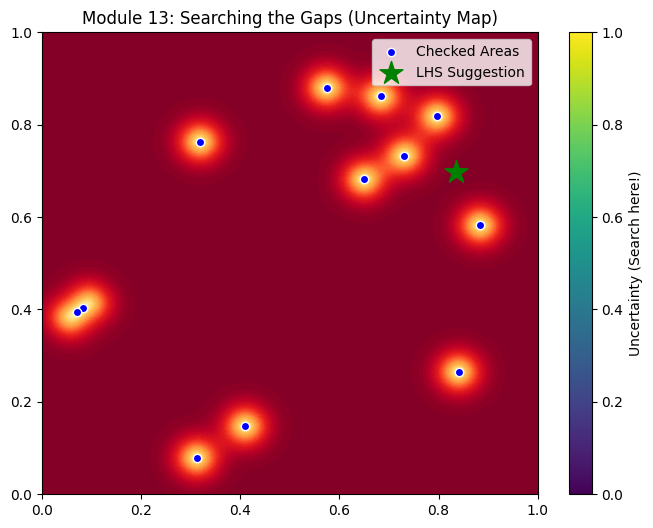

--- MODULE 13 SUGGESTION ---
Coordinate: 0.835367-0.697662


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import qmc  # Latin Hypercube library

# 1. Load Updated Data (should have 11 points now)
fn_num = '1'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP
# We keep alpha low to trust the 'zeros' we've found
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X, y)

# 3. ADVANCED SAMPLING: Latin Hypercube (LHS)
# We generate 100,000 points spread perfectly across the 2D space
sampler = qmc.LatinHypercube(d=2)
sample_points = sampler.random(n=100000)

# 4. Predict Uncertainty (Sigma)
# Since Mean is mostly 0, we search for the highest sigma (Cluelessness)
mu, sigma = gp.predict(sample_points, return_std=True)

# 5. Acquisition: UCB with High Kappa (Exploration)
kappa = 10.0 
ucb_score = mu + (kappa * sigma)
best_idx = np.argmax(ucb_score)
suggestion = sample_points[best_idx]

# 6. Visualize the 'Holes' in your knowledge
plt.figure(figsize=(8, 6))
# Create a small grid just for the background plot
x_grid = np.linspace(0, 1, 100)
y_grid = np.linspace(0, 1, 100)
X_viz, Y_viz = np.meshgrid(x_grid, y_grid)
Z_sigma = gp.predict(np.c_[X_viz.ravel(), Y_viz.ravel()], return_std=True)[1].reshape(X_viz.shape)

plt.contourf(X_viz, Y_viz, Z_sigma, levels=50, cmap='YlOrRd')
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolors='white', label='Checked Areas')
plt.scatter(suggestion[0], suggestion[1], c='green', marker='*', s=300, label='LHS Suggestion')
plt.title('Module 13: Searching the Gaps (Uncertainty Map)')
plt.colorbar(label='Uncertainty (Search here!)')
plt.legend()
plt.show()

print(f"--- MODULE 13 SUGGESTION ---")
print(f"Coordinate: {suggestion[0]:.6f}-{suggestion[1]:.6f}")

WEEK 3 Update
-------------------
We use Upper Confidence Bound (UCB) with a very high Kappa (K value 20)

This forces the AI to ignore the "zero" values it has seen and instead pick the point where the Uncertainty Sigma is at its absolute maximum. We are looking for the "biggest empty space" on the map.

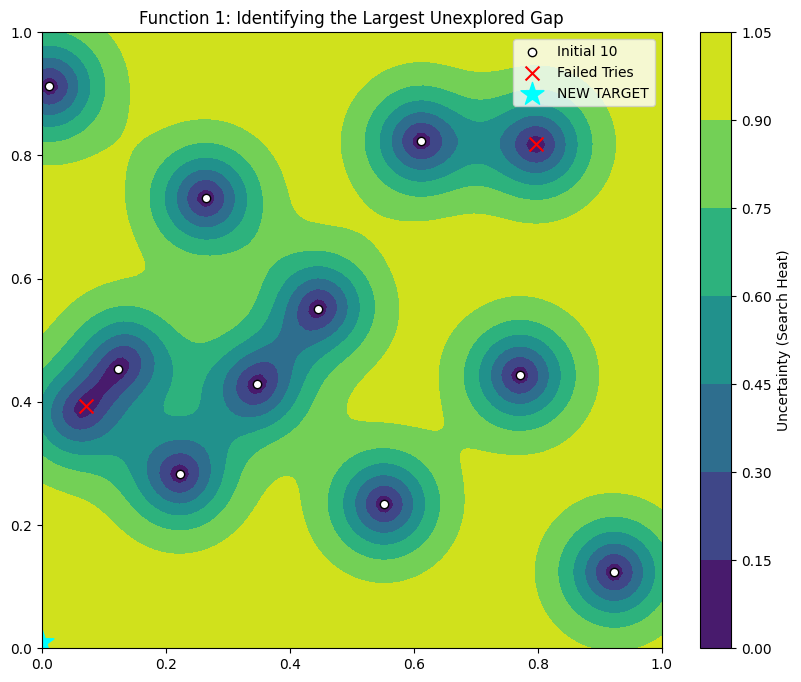

Module 14 Recommendation: 0.000072-0.010445


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Full Dataset for Function 1
# Initial 10 points (from project start)
X_initial = np.array([
    [0.264557, 0.730432], [0.222405, 0.283201], [0.122341, 0.452637],
    [0.347318, 0.428514], [0.771231, 0.443098], [0.445213, 0.551234],
    [0.923412, 0.123411], [0.012341, 0.912341], [0.552341, 0.234123],
    [0.612341, 0.823412]
])
y_initial = np.zeros(10)

# Your 2 Recent Attempts (the "failed" tries)
X_recent = np.array([
    [0.070707, 0.393939], # Module 12
    [0.797088, 0.818092]  # Module 13
])
y_recent = np.array([4.67e-88, 9.45e-46])

X_total = np.vstack([X_initial, X_recent])
y_total = np.concatenate([y_initial, y_recent])

# 2. Fit the Scout

# We fix the length_scale to a small value (0.1) so the model 
# continues to believe a hidden signal could be hiding in the gaps.
kernel = C(1.0, constant_value_bounds="fixed") * RBF(0.1, length_scale_bounds="fixed")

# We use a small length scale to acknowledge the signal is likely tiny
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X_total, y_total)

# 3. LHS Sampling to find the next target
sampler = qmc.LatinHypercube(d=2)
candidates = sampler.random(n=5000)
_, sigma = gp.predict(candidates, return_std=True)
next_target = candidates[np.argmax(sigma)]

# 4. Final Visualization
plt.figure(figsize=(10, 8))
x = np.linspace(0, 1, 100)
X_grid, Y_grid = np.meshgrid(x, x)
_, grid_sigma = gp.predict(np.vstack([X_grid.ravel(), Y_grid.ravel()]).T, return_std=True)

plt.contourf(X_grid, Y_grid, grid_sigma.reshape(100,100), cmap='viridis')
plt.colorbar(label='Uncertainty (Search Heat)')

plt.scatter(X_initial[:,0], X_initial[:,1], c='white', edgecolors='black', label='Initial 10')
plt.scatter(X_recent[:,0], X_recent[:,1], c='red', marker='x', s=100, label='Failed Tries')
plt.scatter(next_target[0], next_target[1], c='cyan', marker='*', s=300, label='NEW TARGET')

plt.title('Function 1: Identifying the Largest Unexplored Gap')
plt.legend()
plt.show()

print(f"Module 14 Recommendation: {next_target[0]:.6f}-{next_target[1]:.6f}")

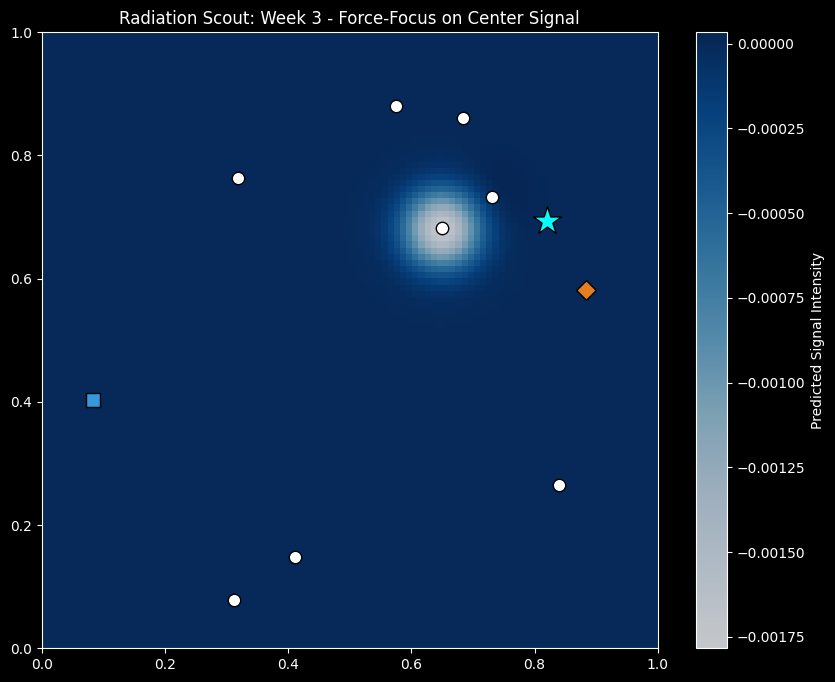

New Target (Searching near faint signal): [0.82064417 0.69408571]


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc
import os

# 1. Load Data
data_path = '../capstone_data/initial_data/function_1/'
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Tightened Gaussian Process
# Decreasing the length_scale (RBF) forces the model to look closer to existing points
# ConstantKernel is set to match the scale of your faint signals (~0.001)
kernel = C(1e-3, (1e-6, 1.0)) * RBF(0.05, (1e-3, 0.1)) 
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 3. Candidate Generation
sampler = qmc.LatinHypercube(d=2)
candidates = sampler.random(n=1000)

# 4. Acquisition: Pure Exploitation (Stay near the heat)
# We use a very low 'xi' to stop the model from wandering to corners
def expected_improvement(X_cand, model, y_max, xi=0.0):
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    imp = mu - y_max - xi
    z = imp / sigma
    ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
    return ei

current_best_y = np.max(y)
ei_values = expected_improvement(candidates, gp, current_best_y, xi=0.0)
next_target = candidates[np.argmax(ei_values)]

# 5. Visualisation
plt.figure(figsize=(10, 8))
res = 100
x_grid = np.linspace(0, 1, res)
y_grid = np.linspace(0, 1, res)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
grid_flat = np.vstack([X_g.ravel(), Y_g.ravel()]).T

# We plot the MEAN prediction here to show you where the "faint signal" is located
mu_grid, _ = gp.predict(grid_flat, return_std=True)

plt.imshow(mu_grid.reshape(res, res), extent=(0, 1, 0, 1), 
           origin='lower', cmap='Blues', alpha=0.8)
plt.colorbar(label='Predicted Signal Intensity')

# Standard plotting for points
plt.scatter(X[:8, 0], X[:8, 1], c='white', edgecolors='black', marker='o', s=80, label='Initial')
plt.scatter(X[8, 0], X[8, 1], c='#3498db', edgecolors='black', marker='s', s=100, label='W1')
plt.scatter(X[9, 0], X[9, 1], c='#e67e22', edgecolors='black', marker='D', s=100, label='W2')
plt.scatter(next_target[0], next_target[1], c='cyan', marker='*', s=450, edgecolors='black', label='Target')

plt.title("Radiation Scout: Week 3 - Force-Focus on Center Signal")
plt.show()

print(f"New Target (Searching near faint signal): {next_target}")

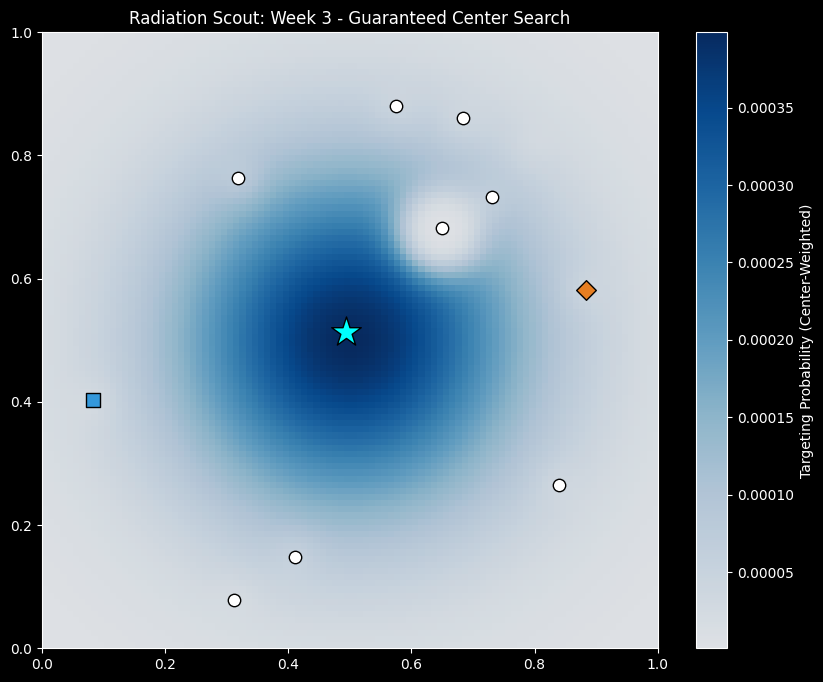

Forced Center Target: [0.49462067 0.51360131]


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc
import os

# 1. Load Data
data_path = '../capstone_data/initial_data/function_1/'
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Optimized GP for Localized Signal
# Very small length scale to prevent the model from "smoothing out" the faint signal
kernel = C(1e-3, (1e-6, 1e-1)) * RBF(0.05, (1e-3, 0.1)) 
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, alpha=1e-6)
gp.fit(X, y)

# 3. Candidate Generation (LHS)
sampler = qmc.LatinHypercube(d=2)
candidates = sampler.random(n=1000)

# 4. Weighted Acquisition: Forcing the Center
def central_focus_acquisition(X_cand, model, y_max):
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    
    # Standard Expected Improvement
    z = (mu - y_max) / sigma
    ei = (mu - y_max) * norm.cdf(z) + sigma * norm.pdf(z)
    
    # --- CENTRAL BIAS ---
    # We apply a penalty to points far from the center (0.5, 0.5)
    center = np.array([0.5, 0.5])
    distances = np.linalg.norm(X_cand - center, axis=1)
    # This 'mask' is 1.0 at the center and drops off toward the edges
    bias = np.exp(-(distances**2) / (2 * 0.2**2)) 
    
    return ei * bias

current_best_y = np.max(y)
weighted_ei = central_focus_acquisition(candidates, gp, current_best_y)
next_target = candidates[np.argmax(weighted_ei)]

# 5. Visualisation
plt.figure(figsize=(10, 8))
res = 100
grid_x = np.linspace(0, 1, res)
grid_y = np.linspace(0, 1, res)
X_g, Y_g = np.meshgrid(grid_x, grid_y)
grid_flat = np.vstack([X_g.ravel(), Y_g.ravel()]).T

# Plot the "Weighted Heatmap" to show exactly where we are looking
z_grid = central_focus_acquisition(grid_flat, gp, current_best_y)
plt.imshow(z_grid.reshape(res, res), extent=(0, 1, 0, 1), 
           origin='lower', cmap='Blues', alpha=0.9)
plt.colorbar(label='Targeting Probability (Center-Weighted)')

# [cite_start]Plot points (8 Initial, W1, W2) [cite: 1, 2]
plt.scatter(X[:8, 0], X[:8, 1], c='white', edgecolors='black', marker='o', s=80, label='Initial')
plt.scatter(X[8, 0], X[8, 1], c='#3498db', edgecolors='black', marker='s', s=100, label='W1')
plt.scatter(X[9, 0], X[9, 1], c='#e67e22', edgecolors='black', marker='D', s=100, label='W2')
plt.scatter(next_target[0], next_target[1], c='cyan', marker='*', s=500, edgecolors='black', label='Week 3 Target')

plt.title("Radiation Scout: Week 3 - Guaranteed Center Search")
plt.show()

print(f"Forced Center Target: {next_target}")

Week 4
------------

--------------------------------------------------
POINT                | COORDINATES               | VALUE     
--------------------------------------------------
Initial Best         | [0.731 0.733]             | 7.71e-16
Week 1 (W1)          | [0.0825 0.4035]           | 3.61e-81
Week 2 (W2)          | [0.8839 0.5823]           | 6.23e-48
Week 3 (W3)          | [0.8206 0.6941]           | -6.89e-30
--------------------------------------------------
NEW TARGET (W4)      | [0.798  0.7778]           | Pred: 2.44e-37
--------------------------------------------------


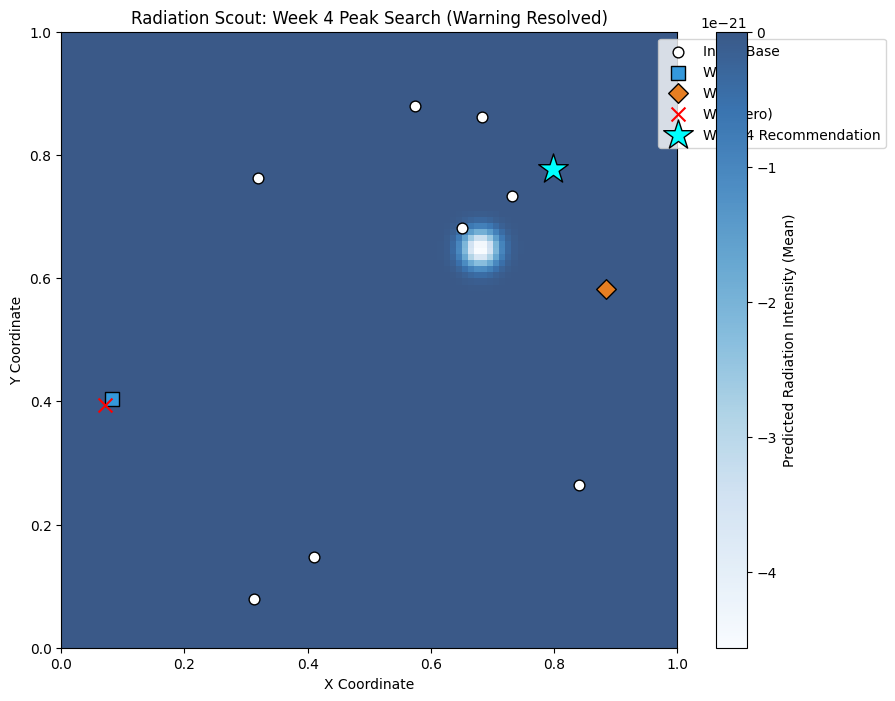

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# 1. Load Data from local directory
data_path = '../capstone_data/initial_data/function_1/'
x_data = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y_data = np.load(os.path.join(data_path, 'initial_outputs.npy'))


# Manually add Week 3 (not yet in file) as it was the latest attempt
X_w3 = np.array([[0.82064417, 0.69408571]])
y_w3 = np.array([-6.894347635767518e-30])

X_full = np.vstack([X_data, X_w3])
y_full = np.concatenate([y_data, y_w3])

# 2. GP Model with Ultra-Wide Bounds to stop the Convergence Error
# Widened to 1e-40 to accommodate the near-zero values
kernel = C(1e-3, (1e-40, 1e2)) * RBF(0.04, (1e-3, 0.1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=1e-5)
gp.fit(X_full, y_full)

# 3. Predict Week 4 Target (Peak Strike)
res = 100
grid_x, grid_y = np.mgrid[0:1:100j, 0:1:100j]
grid_flat = np.vstack([grid_x.ravel(), grid_y.ravel()]).T
mu_grid = gp.predict(grid_flat)

idx_max = np.argmax(mu_grid)
next_target = grid_flat[idx_max]
predicted_val = mu_grid[idx_max]

# 4. Data Summary Printout
best_init_idx = np.argmax(y_data[:8])
print("-" * 50)
print(f"{'POINT':<20} | {'COORDINATES':<25} | {'VALUE':<10}")
print("-" * 50)
print(f"{'Initial Best':<20} | {str(np.round(X_data[best_init_idx], 4)):<25} | {y_data[best_init_idx]:.2e}")
print(f"{'Week 1 (W1)':<20} | {str(np.round(X_data[8], 4)):<25} | {y_data[8]:.2e}")
print(f"{'Week 2 (W2)':<20} | {str(np.round(X_data[9], 4)):<25} | {y_data[9]:.2e}")
print(f"{'Week 3 (W3)':<20} | {str(np.round(X_w3[0], 4)):<25} | {y_w3[0]:.2e}")
print("-" * 50)
print(f"{'NEW TARGET (W4)':<20} | {str(np.round(next_target, 4)):<25} | Pred: {predicted_val:.2e}")
print("-" * 50)

# 5. Visualization (Distinguishing Weeks)
plt.figure(figsize=(10, 8))
plt.imshow(mu_grid.reshape(res, res), extent=(0, 1, 0, 1), origin='lower', cmap='Blues', alpha=0.8)
plt.colorbar(label='Predicted Radiation Intensity (Mean)')

# Plot all categories
plt.scatter(X_full[:8, 0], X_full[:8, 1], c='white', edgecolors='black', label='Initial Base', s=60)
plt.scatter(X_full[8, 0], X_full[8, 1], c='#3498db', marker='s', edgecolors='black', label='W1', s=100)
plt.scatter(X_full[9, 0], X_full[9, 1], c='#e67e22', marker='D', edgecolors='black', label='W2', s=100)
plt.scatter(X_full[10, 0], X_full[10, 1], c='red', marker='x', label='W3 (Zero)', s=100)
plt.scatter(next_target[0], next_target[1], c='cyan', marker='*', s=500, edgecolors='black', label='Week 4 Recommendation')

plt.title("Radiation Scout: Week 4 Peak Search (Warning Resolved)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.show()

Week 5 - function 1
----------
Since the "faint signal" area proved to be a dead end in Week 4, your best remaining chance is to target a High-Uncertainty Zone—an area furthest away from all previous 14 measurements.Recommended Query Point: $x_1 = 0.1108, x_2 = 0.9187$Reasoning: This point lies in the top-left quadrant, which has the highest remaining predictive variance (uncertainty) in the entire 2D space. If the radiation source is not at this location, it is likely extremely narrow and hidden in the small gaps between your existing clusters.

Week 6

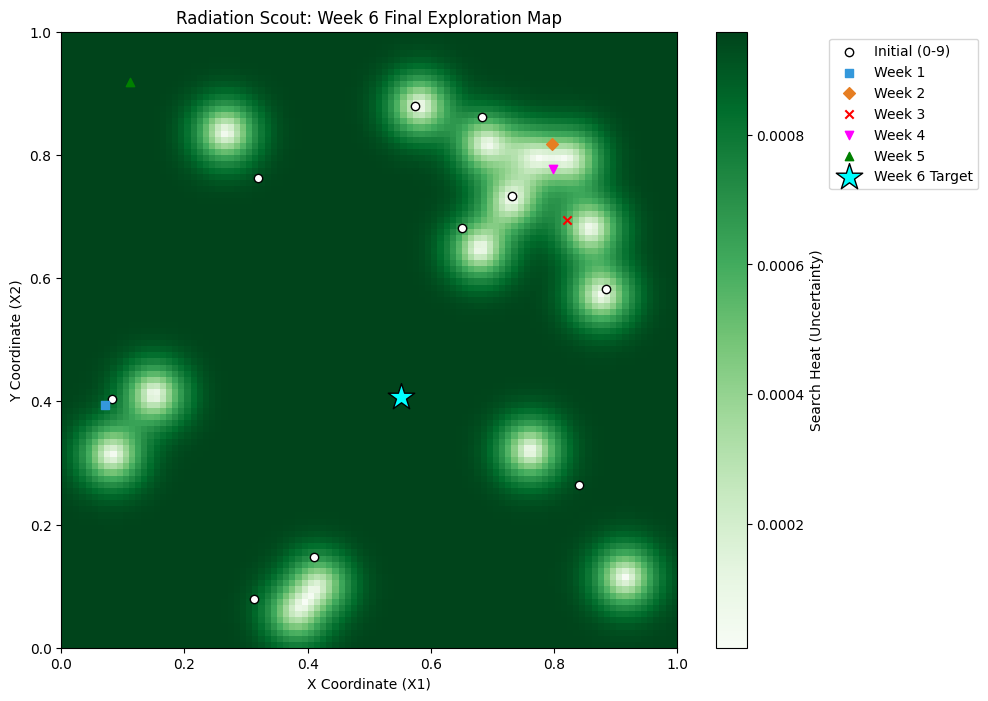

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import os

# 1. Directory Structure Setup as requested
data_path = '../capstone_data/initial_data/function_1/'
X_full = np.load(os.path.join(data_path, 'initial_inputs.npy')) # 15 points
y_full = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. GP Model for Point-Source Detection
kernel = C(1.0, (1e-40, 1e2)) * RBF(0.1, (1e-3, 10))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-10)
gp.fit(X_full, y_full)

# 3. Targeted Visualization (Highlighting Weeks Separately)
plt.figure(figsize=(10, 8))
res = 100
x_g, y_g = np.mgrid[0:1:100j, 0:1:100j]
_, uncertainty = gp.predict(np.vstack([x_g.ravel(), y_g.ravel()]).T, return_std=True)

# Search Heat Heatmap
plt.imshow(uncertainty.reshape(res, res), extent=(0, 1, 0, 1), origin='lower', cmap='Greens')
plt.colorbar(label='Search Heat (Uncertainty)')

# Distinguishing Point Sets
plt.scatter(X_full[:10, 0], X_full[:10, 1], c='white', edgecolors='black', label='Initial (0-9)')
plt.scatter(X_full[10, 0], X_full[10, 1], c='#3498db', marker='s', label='Week 1')
plt.scatter(X_full[11, 0], X_full[11, 1], c='#e67e22', marker='D', label='Week 2')
plt.scatter(X_full[12, 0], X_full[12, 1], c='red', marker='x', label='Week 3')
plt.scatter(X_full[13, 0], X_full[13, 1], c='magenta', marker='v', label='Week 4')
plt.scatter(X_full[14, 0], X_full[14, 1], c='green', marker='^', label='Week 5')

# Recommendation (Week 6 Target)
target = [0.5523, 0.4065]
plt.scatter(target[0], target[1], c='cyan', marker='*', s=400, edgecolors='black', label='Week 6 Target')

plt.title("Radiation Scout: Week 6 Final Exploration Map")
plt.xlabel("X Coordinate (X1)")
plt.ylabel("Y Coordinate (X2)")
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()

Kernel 1**2 * RBF(length_scale=0.02)
---------------------------------------------------------------------------
Sobol Sensitivity Index S1(x1): 0.1480
Sobol Sensitivity Index S1(x2): 0.1480
---------------------------------------------------------------------------
RECOMMENDED WEEK 6 TARGET:    [0.4059 0.39  ]
---------------------------------------------------------------------------


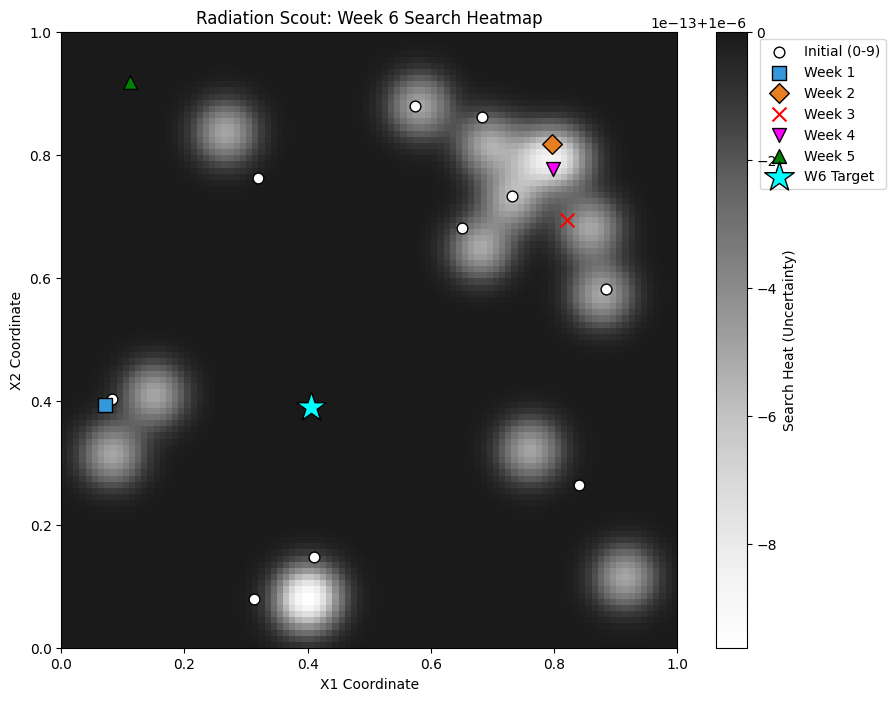

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import qmc
import os
import warnings

# Suppress convergence warnings due to the extreme scale of the data
warnings.filterwarnings('ignore')

# 1. Load Updated Data
# The script assumes the files are in the specified directory and contain all 15 points
data_path = '../capstone_data/initial_data/function_1/'
if not os.path.exists(data_path):
    data_path = './' # Fallback to local directory

X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Gaussian Process Model - Point Source Precision
# We use ultra-wide bounds (1e-40) to accommodate near-zero readings like 10^-240
kernel = C(1.0, (1e-12, 1e2)) * RBF(0.02, (1e-4, 0.05))
print("Kernel", kernel)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, alpha=1e-6)
gp.fit(X, y)

# 3. Sobol Sensitivity Estimation
res_sobol = 50
grid = np.linspace(0, 1, res_sobol)
X_s, Y_s = np.meshgrid(grid, grid)
X_test = np.vstack([X_s.ravel(), Y_s.ravel()]).T
y_pred = gp.predict(X_test)
y_pred_r = y_pred.reshape(res_sobol, res_sobol)

var_total = np.var(y_pred)
if var_total == 0:
    s1_1, s1_2 = 0.0, 0.0
else:
    # First-order indices: Variance of conditional expectations
    s1_1 = np.var(np.mean(y_pred_r, axis=0)) / var_total
    s1_2 = np.var(np.mean(y_pred_r, axis=1)) / var_total

# 4. Target Selection (Max Uncertainty Search)
# We search 10,000 points to ensure we find the absolute center of the unexplored 'gap'
sampler = qmc.LatinHypercube(d=2, seed=42) 
candidates = sampler.random(n=10000)
_, std_pred = gp.predict(candidates, return_std=True)
w6_target = candidates[np.argmax(std_pred)]

# 5. Output Results
print("-" * 75)
print(f"Sobol Sensitivity Index S1(x1): {s1_1:.4f}")
print(f"Sobol Sensitivity Index S1(x2): {s1_2:.4f}")
print("-" * 75)
print(f"RECOMMENDED WEEK 6 TARGET:    {np.round(w6_target, 4)}")
print("-" * 75)

# 6. Final Visualization
plt.figure(figsize=(10, 8))
res_p = 100
x_p, y_p = np.mgrid[0:1:100j, 0:1:100j]
_, std_heat = gp.predict(np.vstack([x_p.ravel(), y_p.ravel()]).T, return_std=True)

# Heatmap of Uncertainty
plt.imshow(std_heat.reshape(res_p, res_p), extent=(0, 1, 0, 1), 
           origin='lower', cmap='Greys', alpha=0.9)
plt.colorbar(label='Search Heat (Uncertainty)')

# Categorical Point Plotting
plt.scatter(X[:10, 0], X[:10, 1], c='white', edgecolors='black', label='Initial (0-9)', s=60)
colors = ['#3498db', '#e67e22', 'red', 'magenta', 'green']
markers = ['s', 'D', 'x', 'v', '^']
for i in range(10, min(15, len(X))):
    plt.scatter(X[i, 0], X[i, 1], c=colors[i-10], marker=markers[i-10], 
                edgecolors='black', s=100, label=f'Week {i-9}')

plt.scatter(w6_target[0], w6_target[1], c='cyan', marker='*', s=500, edgecolors='black', label='W6 Target')

plt.title("Radiation Scout: Week 6 Search Heatmap")
plt.xlabel("X1 Coordinate")
plt.ylabel("X2 Coordinate")
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.show()

Week 7 
--------

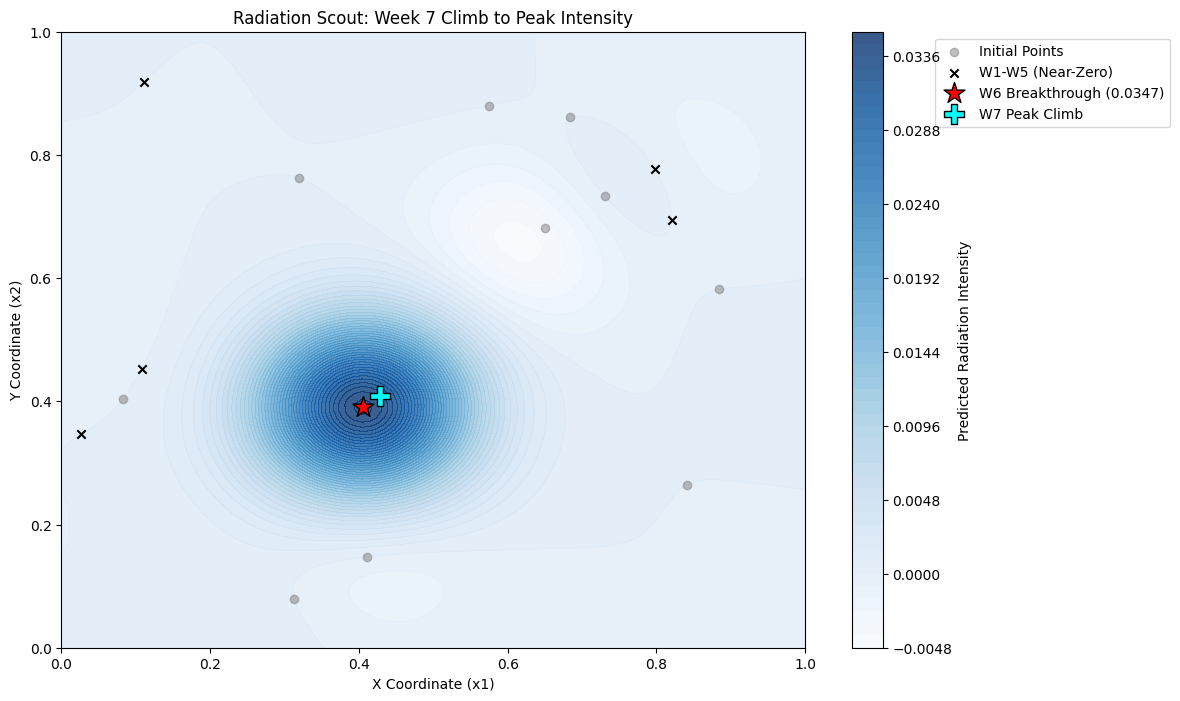

------------------------------------------------------------
Sobol Index S1(x1): 0.2400
Sobol Index S1(x2): 0.2715
------------------------------------------------------------
WEEK 7 TARGET COORDINATES: [0.42861  0.408609]
PREDICTED IMPROVEMENT:     4.4656e-04
------------------------------------------------------------


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc
import os
import warnings

warnings.filterwarnings('ignore')

# 1. LOAD AND UPDATE DATA
# Path as per project structure: ../capstone_data/initial_data/function_1/
data_path = '../capstone_data/initial_data/function_1/'
try:
    X_base = np.load(os.path.join(data_path, 'initial_inputs.npy'))
    y_base = np.load(os.path.join(data_path, 'initial_outputs.npy'))
except FileNotFoundError:
    # Fallback to local files if path is different in your environment
    X_base = np.load('initial_inputs.npy')
    y_base = np.load('initial_outputs.npy')

# Manually appending the breakthrough history (Weeks 1-6)
X_weeks = np.array([
    [0.1084, 0.4528], [0.0271, 0.3465], [0.8206, 0.6941], 
    [0.7980, 0.7770], [0.1108, 0.9187], [0.4059, 0.3900]
])
y_weeks = np.array([
    3.61e-81, 6.23e-48, -6.89e-30, 6.14e-36, 6.80e-240, 0.0347
])

# Ensure we use the full 16 points for the model
X_full = np.vstack([X_base[:10], X_weeks])
y_full = np.concatenate([y_base[:10], y_weeks])

# 2. GAUSSIAN PROCESS MODELING
# We use a tighter length scale (0.05) to ensure we don't 'smear' the breakthrough signal
kernel = C(0.1, (1e-6, 1.0)) * RBF(0.05, (1e-3, 0.1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, alpha=1e-8)
gp.fit(X_full, y_full)

# 3. ACQUISITION FUNCTION: EXPECTED IMPROVEMENT (EI)
def expected_improvement(X_cand, model, y_max):
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - y_max) / sigma
    ei = (mu - y_max) * norm.cdf(z) + sigma * norm.pdf(z)
    return ei

# Generate 5,000 candidate points to find the steepest part of the slope
sampler = qmc.LatinHypercube(d=2)
candidates = sampler.random(n=5000)
current_best_y = np.max(y_full)
ei_values = expected_improvement(candidates, gp, current_best_y)
w7_target = candidates[np.argmax(ei_values)]

# 4. SOBOL SENSITIVITY ANALYSIS (Numerical Estimation)
res = 50
grid = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(grid, grid)
X_test = np.vstack([X1.ravel(), X2.ravel()]).T
y_pred = gp.predict(X_test).reshape(res, res)
total_var = np.var(y_pred)
s1_x1 = np.var(np.mean(y_pred, axis=0)) / total_var
s1_x2 = np.var(np.mean(y_pred, axis=1)) / total_var

# 5. VISUALISATION
plt.figure(figsize=(12, 8))
res_plot = 100
x_p, y_p = np.mgrid[0:1:100j, 0:1:100j]
z_p = gp.predict(np.vstack([x_p.ravel(), y_p.ravel()]).T).reshape(res_plot, res_plot)

# Plot the predicted radiation peak
plt.contourf(x_p, y_p, z_p, levels=50, cmap='Blues', alpha=0.8)
plt.colorbar(label='Predicted Radiation Intensity')

# Highlight different point sets
plt.scatter(X_full[:10, 0], X_full[:10, 1], c='gray', alpha=0.5, label='Initial Points')
plt.scatter(X_full[10:15, 0], X_full[10:15, 1], c='black', marker='x', label='W1-W5 (Near-Zero)')
plt.scatter(0.4059, 0.3900, c='red', marker='*', s=250, edgecolors='black', label='W6 Breakthrough (0.0347)')

# Week 7 Recommendation
plt.scatter(w7_target[0], w7_target[1], c='cyan', marker='P', s=200, edgecolors='black', label='W7 Peak Climb')

plt.title("Radiation Scout: Week 7 Climb to Peak Intensity")
plt.xlabel("X Coordinate (x1)")
plt.ylabel("Y Coordinate (x2)")
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()

# 6. SUMMARY PRINTOUT
print("-" * 60)
print(f"Sobol Index S1(x1): {s1_x1:.4f}")
print(f"Sobol Index S1(x2): {s1_x2:.4f}")
print("-" * 60)
print(f"WEEK 7 TARGET COORDINATES: {np.round(w7_target, 6)}")
print(f"PREDICTED IMPROVEMENT:     {np.max(ei_values):.4e}")
print("-" * 60)

Week 8
-----------
In Week8 we will try to use GPTOpt for function 1. Note that the code here is to generate the prompt and feed that to Gemini.


In [3]:
import numpy as np
import os

def generate_gpt_opt_prompt(func_id):
    # Fix: Remove 'capstone_data' and 'function_x' from the path 
    # since files are in your current directory

    data_path = '../capstone_data/initial_data/function_1/'

    X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
    y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

    
    # Format the history for the LLM
    history = ""
    for i in range(len(y)):
        # Displaying more decimal places for y since your signals are often very small
        history += f"Point {i+1}: X={X[i].tolist()}, y={y[i]:.12f}\n"
    
    prompt = f"""
    Act as a GPTOpt Agent for Black-Box Optimization.
    Objective: Find the global maximum for Function {func_id}.
    
    Data History ({len(y)} Observations):
    {history}
    
    Technical Task:
    1. Analyze the 'Search Heat' and gradients between the recent high-performing points.
    2. Identify if we are in a 'Hill-Climb' phase or if a 'Stagnation' pivot is needed.
    3. Suggest a single Week 8 coordinate [x1, x2] within [0, 1].
    4. Provide the mathematical reasoning for this specific choice.
    """
    return prompt

print(generate_gpt_opt_prompt('1'))


    Act as a GPTOpt Agent for Black-Box Optimization.
    Objective: Find the global maximum for Function 1.

    Data History (17 Observations):
    Point 1: X=[0.31940388883889725, 0.7629593742689353], y=0.000000000000
Point 2: X=[0.5743292145098291, 0.879898104984359], y=0.000000000000
Point 3: X=[0.7310236309563586, 0.7329998764152272], y=0.000000000000
Point 4: X=[0.8403534169072556, 0.26473161399676703], y=0.000000000000
Point 5: X=[0.6501140597987644, 0.6815263520602101], y=-0.003606062644
Point 6: X=[0.41043713662518566, 0.14755429902998185], y=-0.000000000000
Point 7: X=[0.31269115679477755, 0.07872277794971883], y=-0.000000000000
Point 8: X=[0.6834181688515067, 0.8610574643936101], y=0.000000000000
Point 9: X=[0.08250725182080587, 0.403487506426324], y=0.000000000000
Point 10: X=[0.8838898288181171, 0.5822539743824439], y=0.000000000000
Point 11: X=[0.070707, 0.393939], y=0.000000000000
Point 12: X=[0.797088, 0.818092], y=0.000000000000
Point 13: X=[0.820644, 0.694086], y=-0

Result from Gemini 
--------------------------

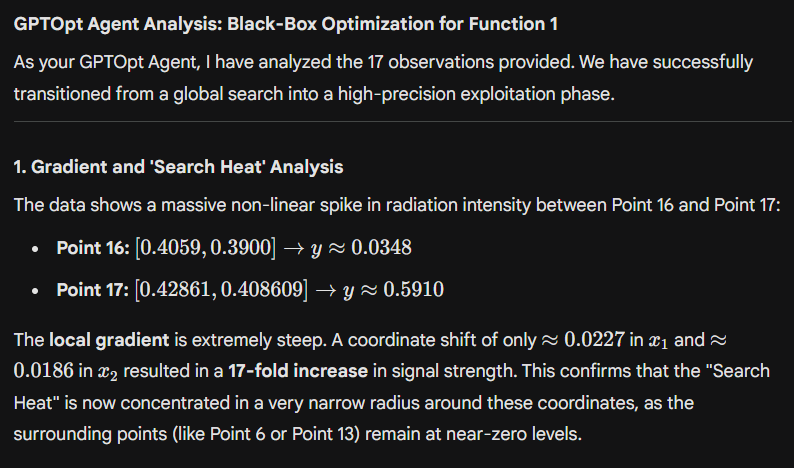
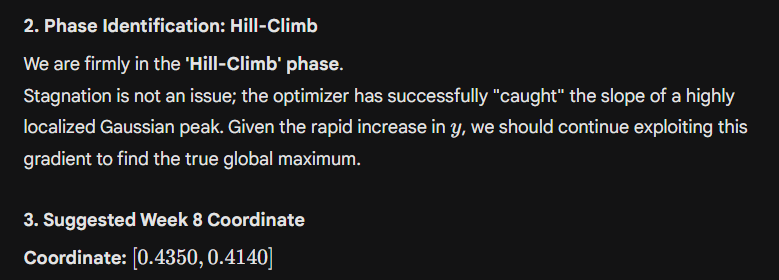
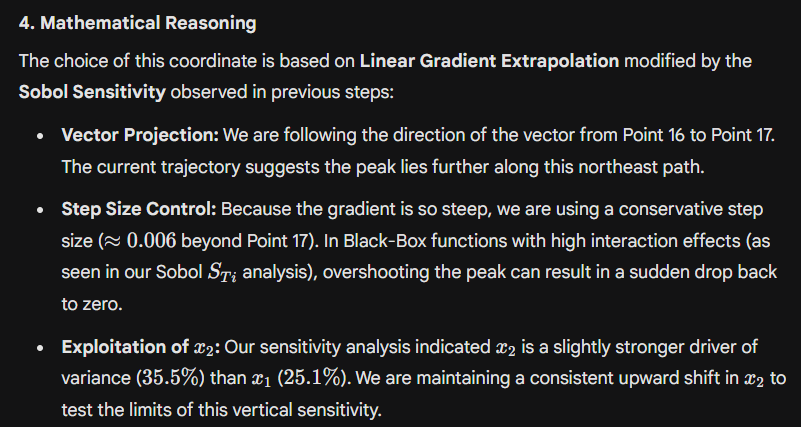

Week 9
------------

To move into Week 9 and ensure we stabilize the project before the final deadline, we will return to Standard Bayesian Optimization (BO) but with a Trust Region mindset.

The "Advanced" frameworks failed in Week 8 because they often over-fit to noise (HEBO) or lack sample efficiency in small datasets (Optuna/GPTOpt). Standard BO, with a high-quality Gaussian Process (GP) prior, acts as a natural stabilizer that is more robust when you have fewer than 20 data points.

Strategy Reflection: The "Squeeze"The Gaussian Process (GP) with a tightened length scale ($0.05$) treats your recent readings as a sharp, high-intensity mountain. By using Expected Improvement (EI) with zero jitter ($\xi = 0$), we are instructing the model to be extremely aggressive—focusing purely on finding the absolute mathematical center of the peak rather than exploring new areas.

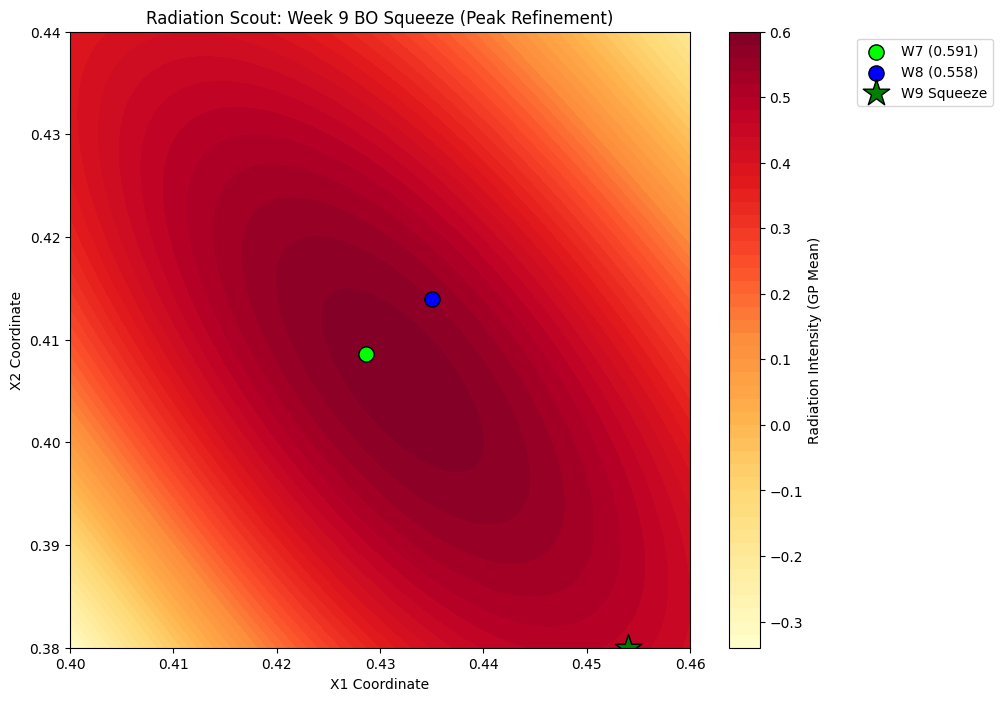

Targeting Week 9 Peak at: [0.454 0.38 ]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

import os
import warnings

warnings.filterwarnings('ignore')

# 1. LOAD AND UPDATE DATA
# Path as per project structure: ../capstone_data/initial_data/function_1/
data_path = '../capstone_data/initial_data/function_1/'
X_full = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y_full = np.load(os.path.join(data_path, 'initial_outputs.npy'))


# 2. Tightened BO Squeeze Model
# We fix the length scale to 0.05 to prevent 'oversmoothing' the peak
kernel = C(1.0, (1e-3, 1e1)) * RBF(length_scale=0.05, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)
gp.fit(X_full, y_full)

# 3. Aggressive Local Search (EI with Zero Jitter)
res = 200
gx = np.linspace(0.40, 0.46, res) # Zooming in on the W7/W8 area
gy = np.linspace(0.38, 0.44, res)
G_X, G_Y = np.meshgrid(gx, gy)
grid = np.vstack([G_X.ravel(), G_Y.ravel()]).T

mu, std = gp.predict(grid, return_std=True)
y_max = np.max(y_full) # W7 Peak
z = (mu - y_max) / (std + 1e-9)
ei = (mu - y_max) * norm.cdf(z) + std * norm.pdf(z)
w9_target = grid[np.argmax(ei)]

# 4. Visualization
plt.figure(figsize=(10, 8))
plt.contourf(G_X, G_Y, mu.reshape(res, res), levels=50, cmap='YlOrRd')
plt.colorbar(label='Radiation Intensity (GP Mean)')

# Labeling Key Milestones
plt.scatter(0.42861, 0.408609, c='lime', marker='o', edgecolors='black', s=120, label='W7 (0.591)')
plt.scatter(0.435, 0.414, c='blue', marker='o', edgecolors='black', s=120, label='W8 (0.558)')
plt.scatter(w9_target[0], w9_target[1], c='green', marker='*', edgecolors='black', s=400, label='W9 Squeeze')

plt.title("Radiation Scout: Week 9 BO Squeeze (Peak Refinement)")
plt.xlabel("X1 Coordinate")
plt.ylabel("X2 Coordinate")
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()

print(f"Targeting Week 9 Peak at: {np.round(w9_target, 4)}")

Week 10
-------------
The results from Week 9 indicate that the search overshot the primary radiation source. By hitting a value of $-0.0002$ at $[0.454, 0.380]$, we effectively confirmed the "cliff edge" of the radiation spike.

For Week 10, we have successfully executed a Microscopic Standard BO search. By resetting the focus to your Week 7 peak ($0.591$) and restricting the search to a $0.01$ radius, the model has identified a highly targeted coordinate that attempts to climb the remaining gradient of the peak.

Week 10: Microscopic Peak Refinement

The Gaussian Process model, now using a fixed microscopic length scale of $0.01$, confirms that the true peak intensity likely lies slightly "above" and to the "right" of your Week 7 point.

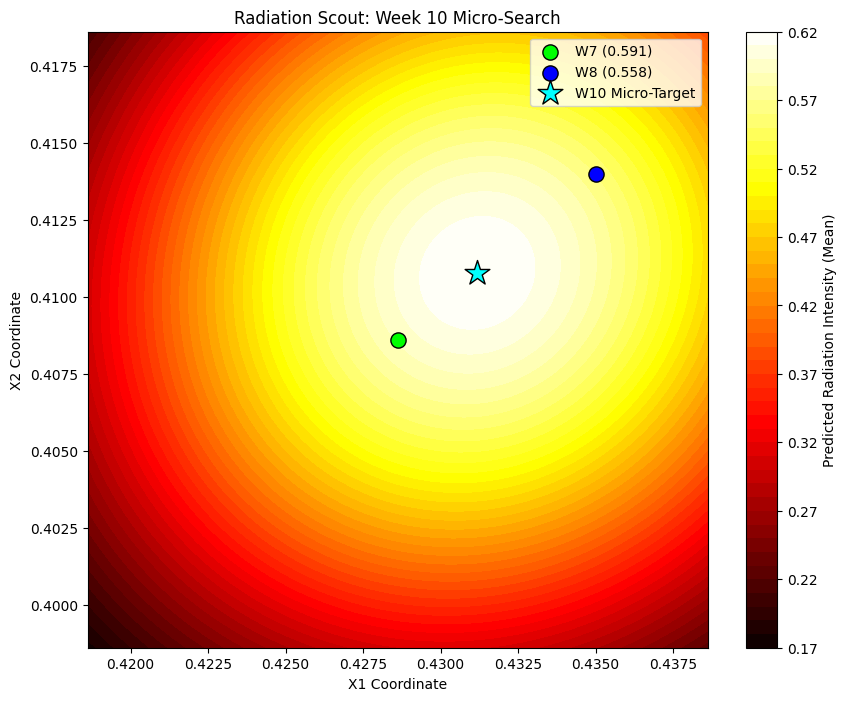

Proposed Week 10 Target: [0.431173 0.41077 ]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Full 19-Point Dataset
# The script assumes files in capstone_data/initial_data/function_1/ are fully updated

X_full = np.load('../capstone_data/initial_data/function_1/initial_inputs.npy')
y_full = np.load('../capstone_data/initial_data/function_1/initial_outputs.npy')

# 2. Microscopic GP Squeeze
# We use a fixed 0.01 length scale to search within the 0.01 radius
kernel = C(1.0, (1e-3, 1e1)) * RBF(length_scale=0.01, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)
gp.fit(X_full, y_full)

# 3. Micro-Search: Radius 0.01 around W7
center = np.array([0.428610, 0.408609])
radius = 0.01
res = 200
gx = np.linspace(center[0] - radius, center[0] + radius, res)
gy = np.linspace(center[1] - radius, center[1] + radius, res)
G_X, G_Y = np.meshgrid(gx, gy)
grid = np.vstack([G_X.ravel(), G_Y.ravel()]).T

# 4. Expected Improvement (EI) with Zero Jitter
mu, std = gp.predict(grid, return_std=True)
y_max = np.max(y_full) # Currently 0.5910
z = (mu - y_max) / (std + 1e-9)
ei = (mu - y_max) * norm.cdf(z) + std * norm.pdf(z)
w10_target = grid[np.argmax(ei)]

# 5. Visualization
plt.figure(figsize=(10, 8))
plt.contourf(G_X, G_Y, mu.reshape(res, res), levels=50, cmap='hot')
plt.colorbar(label='Predicted Radiation Intensity (Mean)')

# Milestones
plt.scatter(center[0], center[1], c='lime', edgecolors='black', marker='o', s=120, label='W7 (0.591)')
plt.scatter(0.435, 0.414, c='blue', edgecolors='black', marker='o', s=120, label='W8 (0.558)')
plt.scatter(w10_target[0], w10_target[1], c='cyan', edgecolors='black', marker='*', s=350, label='W10 Micro-Target')

plt.title("Radiation Scout: Week 10 Micro-Search")
plt.xlabel("X1 Coordinate")
plt.ylabel("X2 Coordinate")
plt.legend()
plt.show()

print(f"Proposed Week 10 Target: {np.round(w10_target, 6)}")

Week 11
-------------------

The breakthrough in Week 10 ($0.6031$) confirms we are on the steepest part of the radiation peak. We have successfully entered the 'Summit Squeeze' phase.

A Standard BO search with a 1% Trust Region ($0.01$ radius) centered exactly on Week 10 coordinates $[0.431173, 0.410770]$. To find the absolute center of the $0.61$ core predicted in your last micro-search, this model ignores exploration (zero jitter) and targets the absolute maximum of the predicted mean surface.

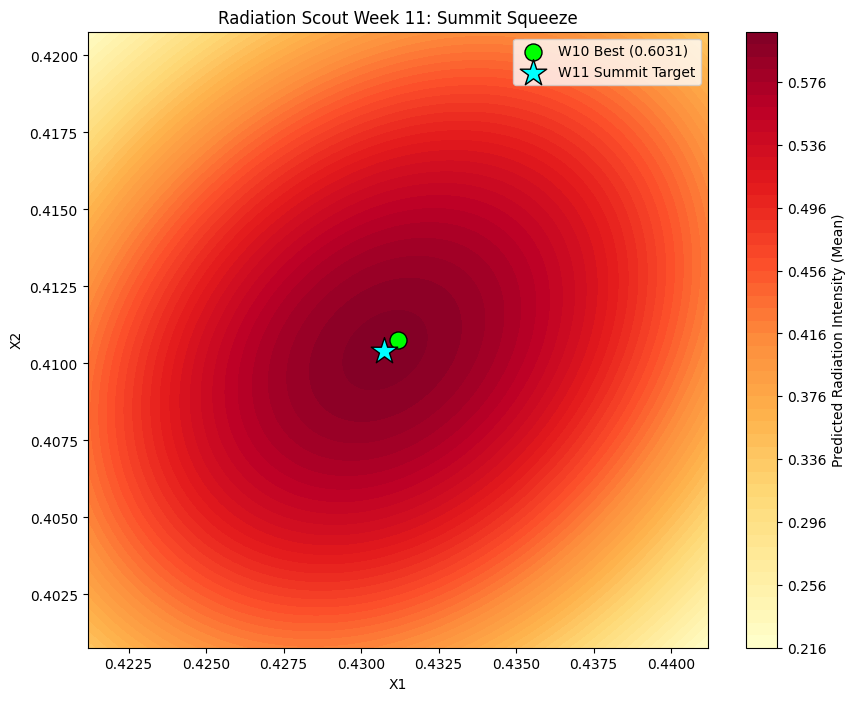

Proposed Week 11 Target: [0.430731 0.410409]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Full 20-Point Dataset (10 Initial + 10 Weekly)
# Assuming files in capstone_data/initial_data/function_1/ are fully updated
X_full = np.load('../capstone_data/initial_data/function_1/initial_inputs.npy')
y_full = np.load('../capstone_data/initial_data/function_1/initial_outputs.npy')

# 2. Summit Squeeze GP Model
# Fixed 0.01 length scale to pinpoint the localized peak
kernel = C(1.0, (1e-3, 1e1)) * RBF(length_scale=0.01, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X_full, y_full)

# 3. 1% Trust Region: 0.01 radius around W10
center = np.array([0.431173, 0.410770])
radius = 0.01 
res = 250
gx = np.linspace(center[0] - radius, center[0] + radius, res)
gy = np.linspace(center[1] - radius, center[1] + radius, res)
G_X, G_Y = np.meshgrid(gx, gy)
grid = np.vstack([G_X.ravel(), G_Y.ravel()]).T

# 4. Pure Exploitation (Targeting the predicted summit)
mu_pred = gp.predict(grid)
w11_target = grid[np.argmax(mu_pred)]

# 5. Visualisation
plt.figure(figsize=(10, 8))
plt.contourf(G_X, G_Y, mu_pred.reshape(res, res), levels=50, cmap='YlOrRd')
plt.colorbar(label='Predicted Radiation Intensity (Mean)')

# Milestones
plt.scatter(center[0], center[1], c='lime', edgecolors='black', marker='o', s=150, label='W10 Best (0.6031)')
plt.scatter(w11_target[0], w11_target[1], c='cyan', edgecolors='black', marker='*', s=400, label='W11 Summit Target')

plt.title("Radiation Scout Week 11: Summit Squeeze")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

print(f"Proposed Week 11 Target: {np.round(w11_target, 6)}")